In [75]:
# =========================================
# 🚀 Setup for Google Colab
# =========================================

# Install SpectroChemPy with CP (TensorLy)
!pip install -q "spectrochempy[cp] @ git+https://github.com/atravert/spectrochempy.git@feature/CP" >& install.log

# Clone the repo
!git clone https://github.com/atravert/psd_raman_hoyer.git

# Move into repo
%cd psd_raman_hoyer

# Check structure
from pathlib import Path
DATA = Path("data")

assert DATA.exists(), "❌ data/ folder missing after clone"

print("✅ Setup complete")

>& was unexpected at this time.


c:\Users\Arnaud\Dropbox\Python\Moi\psd_hoyer\psd_raman_hoyer
✅ Setup complete


fatal: destination path 'psd_raman_hoyer' already exists and is not an empty directory.


## Analysis of Raman MES data from Hoyer et al. (2024)

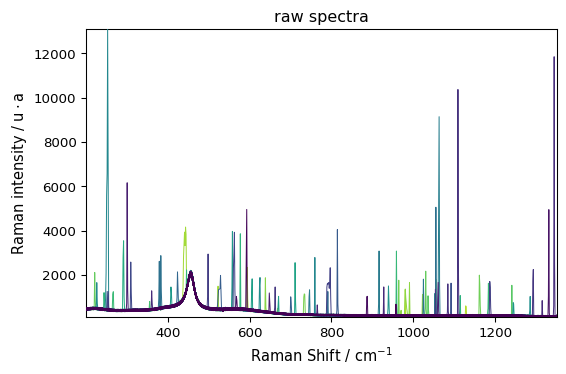

In [76]:
# Imports

import numpy as np
import spectrochempy as scp
import utilities as u
from importlib import reload
import matplotlib.pyplot as plt 

from pathlib import Path

ROOT = Path.cwd()
DATA = ROOT / "data"

assert DATA.exists(), "data folder not found"

# read raw raman data
D_1 = u.read_raman_raw('data/Fig_2-a-c_raw-data.txt')
D_1.y -= D_1.y[0] 
D_1.plot(title='raw spectra')
scp.show()


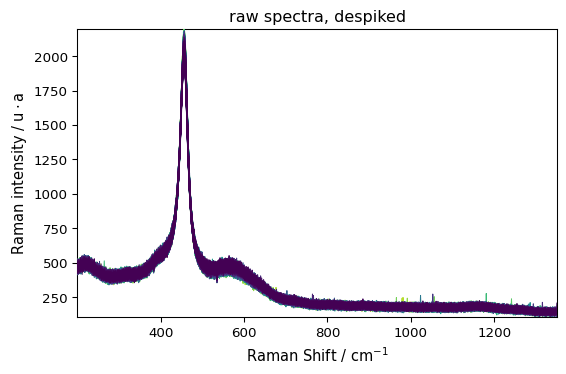

In [77]:
# remove spikes

D_2 = D_1.copy()
diff = D_1[1:] - D_1[:-1]
spectrum, spike = np.where(diff.data > 100)
for spec_idx, spike_idx in zip(spectrum, spike):
    D_2.data[spec_idx+1, spike_idx] = 0.5 * (D_1.data[spec_idx+2, spike_idx] + D_1.data[spec_idx, spike_idx])

D_2.plot(title='raw spectra, despiked')
scp.show()

## Analysis of intensities. 

Here we first look at how intensities are changing on baseline points (255. and 1000. cm$^{-1}$) and signal (455. and 563. cm$^{-1}$) 

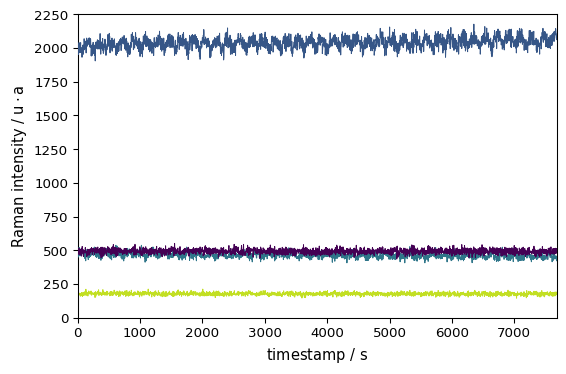

In [80]:
# Single intensites

_ = D_2[:, [225., 455., 563., 1000.]].T.plot(ylim=(0.,2250.))

Visually, there are small tendential increase and decrease of the intensities at 455. and 563., respectively. We can look at the centered difference of intensitiorsn for consistency with the reaction spectrum 

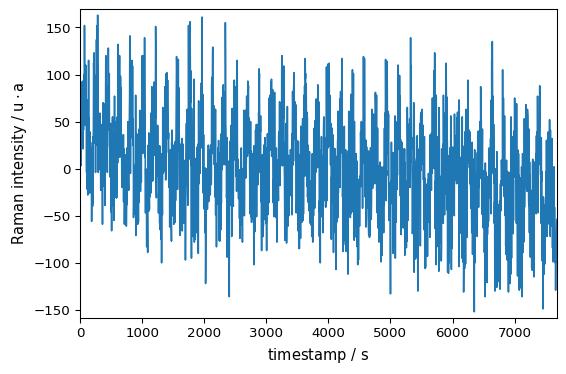

In [81]:
delta_I = D_2[:, 563.] - D_2[:, 455.]
delta_Ic = delta_I - scp.mean(delta_I)  
_ = delta_Ic.plot()

We observe both oscillations and pogressive drift of the mean intensity. To compare their magnitude, we use the 95% confidence interval as a proxy for the amplitude of oscillations and the slope of the linear fit of the intensities.


In [82]:
# Compare the amplitude of oscillations and drift.

ampl = 2 * scp.std(delta_Ic)  
slope =  np.polyfit(delta_I.y.data, delta_I.data, 1)[0]
drift = slope * delta_I.y[-1].data[0] 

print(f"amplitude: {ampl.magnitude:2f} ; drift: {drift}")

amplitude: 100.931022 ; drift: [  -54.16]


The drift over the experiment time represents ~50% of the amplitudes within each cycles.  We can also improve the S/N ratio by using vicinal points, i.e integrating around the maxima.  

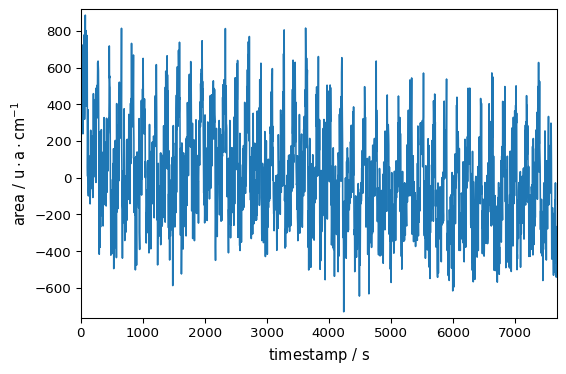

In [83]:
delta_A = - scp.trapezoid(D_2[:,553.:573.]) - scp.trapezoid(D_2[:,450.:470.])
delta_Ac = delta_A - scp.mean(delta_A) 
_ = delta_Ac.plot()

In [84]:
# Compare the amplitude of oscillations and drift.

ampl = 2 * scp.std(delta_Ac)  
slope =  np.polyfit(delta_A.y.data, delta_A.data, 1)[0]
drift = slope * delta_A.y[-1].data[0] 

print(f"amplitude: {ampl.magnitude:2f} ; drift: {drift:2f}")

amplitude: 539.676548 ; drift: -282.490361


We obtain the same trends and order of magnitude.

## Principal Component Analysis


PC	Eigenvalue		%variance		%cumulative
  	 of cov(X)		   per PC		   variance
#1	 1.491e+02		   11.574		     11.574
#2	 4.078e+01		    0.866		     12.439
#3	 3.830e+01		    0.763		     13.203
#4	 3.545e+01		    0.654		     13.857
#5	 3.475e+01		    0.629		     14.485



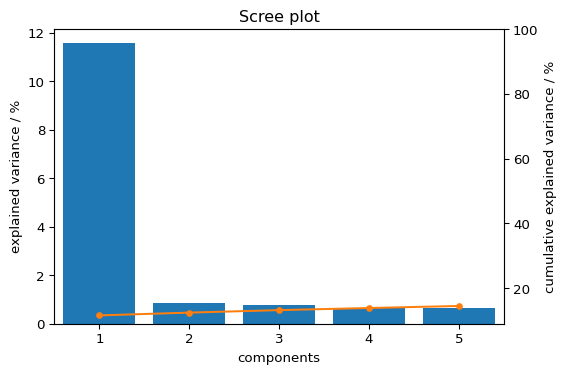

In [85]:
#  statistical analysis in the time domain with PCA

pca = scp.PCA(n_components=5)
pca.fit(D_2)

print(pca)
_ = pca.plot_scree()

## interpretation of the screeplot: 
the 1st component describes 11.6% of the variance. The next ones are of the same order of magnitude and are 
dominated by noise.  This can be confirmed below from the scores of the PCA (note that the signs in PCA are arbitrary: I will multiply scores and
loadings by -1 for consistency with the ppt presentation): 

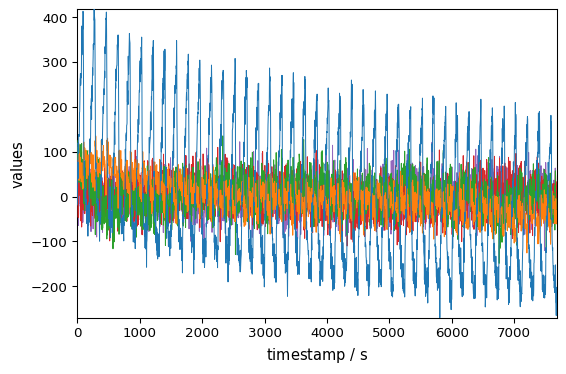

In [86]:

_ =  (- pca.scores).T.plot()

## interpretation of the scores:

The scores of the 1st component (blue) show large oscillations, reflecting the periodic perturbations and a lobal downward trend that suggests a slower evolution over time. The second one (orange) has a much lower amplitude and is noisy, note that it also show a downward trend, but much weaker. The remaining scores are mostly noise.  

In the following I consider only the first component. As it it clearly dominent, inclusion of the other ones should not changhe much the conclusions.

Below we plot the loading (-> a first order approximation of the 'reaction spectrum' ) and the score (the same as above)

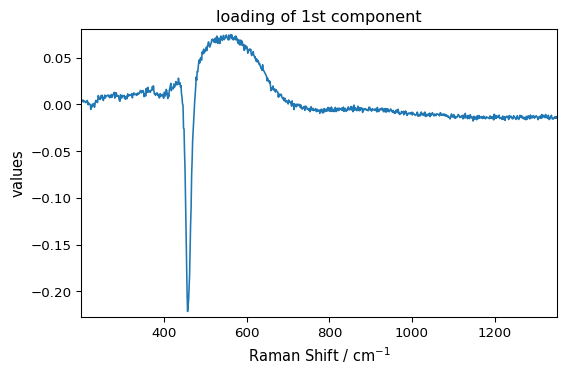

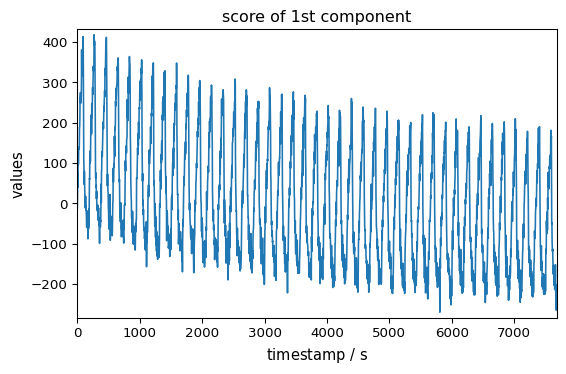

In [87]:

rt = - pca.loadings[0]
x = - pca.scores[:,0]

_ = rt.plot(title='loading of 1st component')
_ = x.plot(title='score of 1st component')

In [74]:
# Compare the amplitude of oscillations and drift.

ampl = 2 * scp.std(x)  
slope =  np.polyfit(x.y.data, x.data, 1)[0]
drift = slope * x.y[-1].data[0] 

print(f"amplitude: {ampl} ; drift: {drift}")

amplitude: 298.19601622044894 ; drift: [  -185.1]


The drift of the first component alos represent a large fraction of the amplitudes.

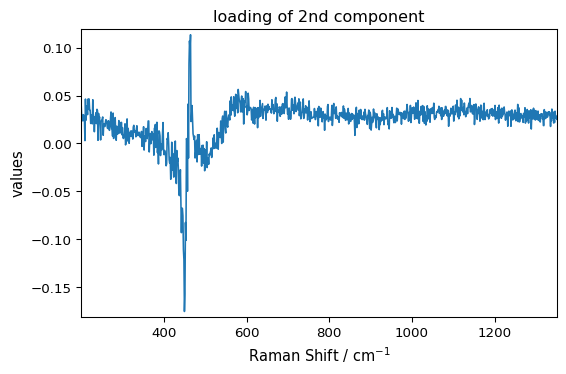

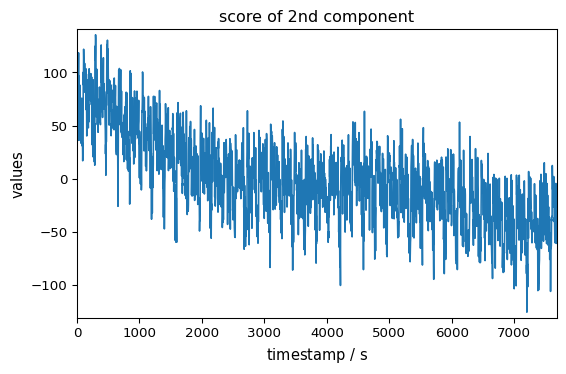

In [88]:
# Note: the second component still has a structured loading, which could reflect some shifts/broadenings of the F2g peak (mentioned in the paper) within each cycle; the fact that score is
# seems also evolving in parallel with that of the 1st component seems to support this  
#    

rt_2 = - pca.loadings[1]
x_2 = - pca.scores[:,1]

_ = rt_2.plot(title='loading of 2nd component')
_ = x_2.plot(title='score of 2nd component')

Coming back to the first component: the scores are changing in terms of both mean and amplitude.  We can assess the change of amplitude within each cycle by computing their standard deviations in each cycle: 
 

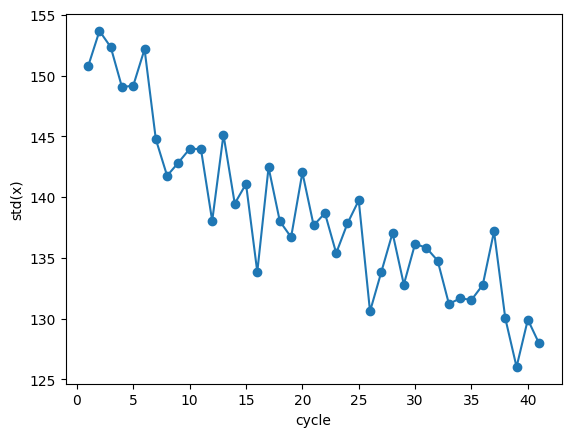

In [89]:
# compute the standard deviation of the scores within each cycle 
N = 41 # cycles
n = 60 # spectra per period

data = np.array(x.data).reshape(N, n)   # (cycles, points_per_cycle)

data_centered = data - data.mean(axis=1, keepdims=True)
std_per_cycle = data.std(axis=1)


plt.figure()
plt.plot(np.arange(N) + 1, std_per_cycle, 'o-')
plt.xlabel('cycle')
plt.ylabel('std(x)')
plt.show()

There is a clear trend showing a progressive decrease in the amplitude of the modulated response in each cycle, indicating that the system becomes less responsive to the excitation. The loss between first and last cycles is ~ 15-20%. 

Note that beyond this decrease in amplitude, there is also a substantial shift of the mean level. 

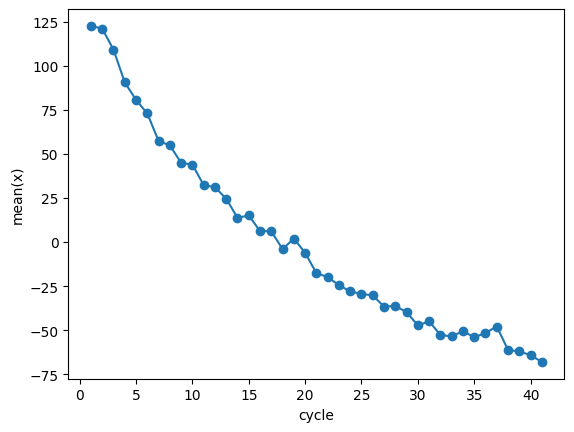

In [90]:
mean_level_per_cycle = data.mean(axis=1)

plt.figure()
plt.plot(np.arange(N) + 1, mean_level_per_cycle, 'o-')
plt.xlabel('cycle')
plt.ylabel('mean(x)')
plt.show()

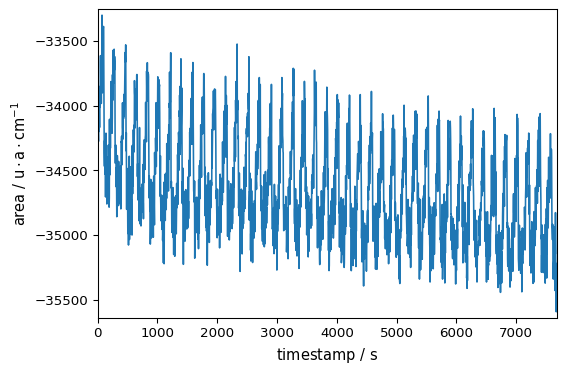

In [91]:
# NB: The varibility between can also be assessed by integrating thez F2g peak  

area = (- D_2[:,445.:465.]).trapezoid()   # I multiply by -1 for consistency 
_ = area.plot()   

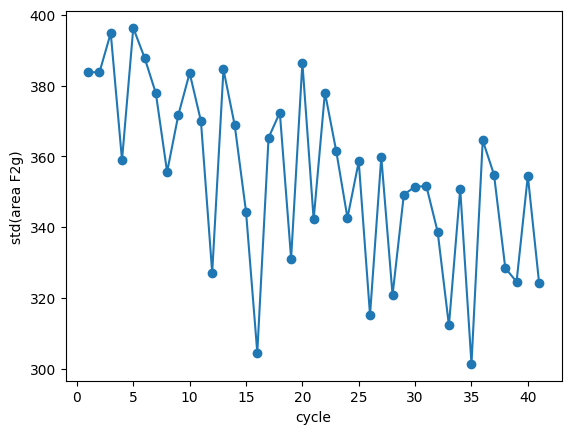

In [92]:
# and process as above to assess the amplitudes of the modulations

data = np.array(area.data).reshape(N, n)   # (cycles, points_per_cycle)

data_centered = data - data.mean(axis=1, keepdims=True)
std_per_cycle = data.std(axis=1)


plt.figure()
plt.plot(np.arange(N) + 1, std_per_cycle, 'o-')
plt.xlabel('cycle')
plt.ylabel('std(area F2g)')
plt.show()

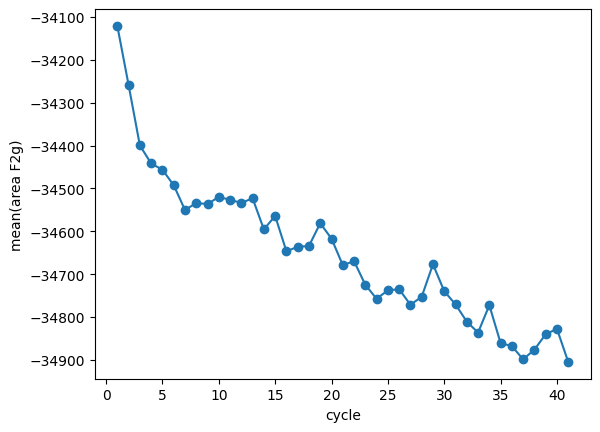

In [ ]:
# and the mean level
mean_level_per_cycle = data.mean(axis=1)

plt.figure()
plt.plot(np.arange(N) + 1, mean_level_per_cycle, 'o-')
plt.xlabel('cycle')
plt.ylabel('mean(area F2g)')
plt.show()

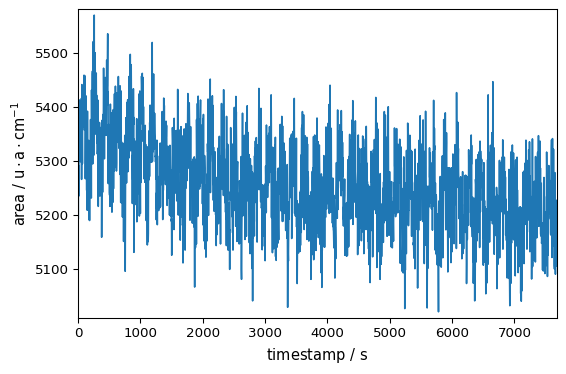

In [ ]:
# NB: The varibility between can also be assessed by integrating around 665 cm-1 

area = D_2[:,655.:675.].trapezoid()    
_ = area.plot()   

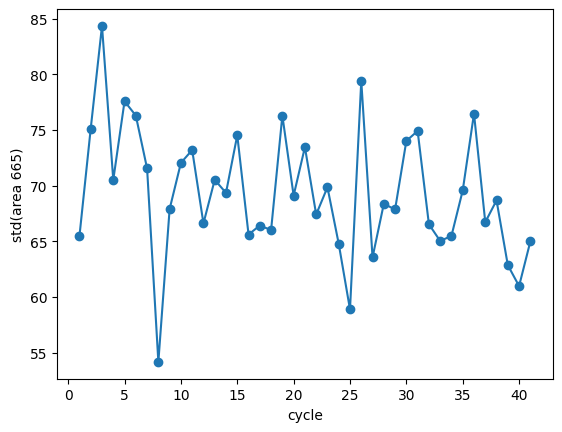

In [ ]:
# in this case there is no trend for the amplitudes of the modulations

data = np.array(area.data).reshape(N, n)   # (cycles, points_per_cycle)

data_centered = data - data.mean(axis=1, keepdims=True)
std_per_cycle = data.std(axis=1)


plt.figure()
plt.plot(np.arange(N) + 1, std_per_cycle, 'o-')
plt.xlabel('cycle')
plt.ylabel('std(area 665)')
plt.show()

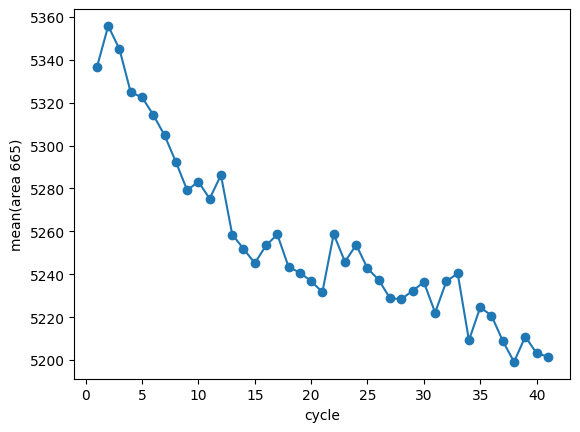

In [ ]:
# but still for the mean level
mean_level_per_cycle = data.mean(axis=1)

plt.figure()
plt.plot(np.arange(N) + 1, mean_level_per_cycle, 'o-')
plt.xlabel('cycle')
plt.ylabel('mean(area 665)')
plt.show()

## CP decomposition

Here a demonstration of CP (or PARAFAC) decompositon. We fist need to create a 3D dataset (N cycles x n spectra per cycle x wavenembers)

In [ ]:
N = 41 # cycles
n = 60 # spectra per period



D_3way = scp.NDDataset(D_2.data.reshape(N, n, D_2.shape[1]))
times = D_2.y.data.reshape(N, n) 
ave_rel_times = np.mean(times - np.expand_dims(times[:,0], axis=1), axis=0)
D_3way.units = D_2.units
D_3way.title = D_2.title
D_3way.set_coordset(z=scp.Coord(np.arange(1, N+1, 1), title='cycle', units=None),
                        y=scp.Coord(ave_rel_times, title='time', units='s'),
                        x= D_2.x)

# Next subtract from each cycle the mean first spectrum. 
D_3way_diff = D_3way - D_3way[:,0,:].data.mean(axis=0)   

# you can have a look at the data structure by clicking on the html output 
D_3way_diff

NDDataset: [float64] u⋅a (shape: (z:41, y:60, x:984))

Now carry out the CP decomposition for 1 an,d 2 components.  

In [ ]:
cp_list = []

for n_components in [1,2]:
    cp = scp.CP(n_components=n_components)
    cp.fit(D_3way_diff)
    print(f'{n_components} components: CC = {cp.core_consistency} ')
    cp_list.append(cp)

1 components: CC = 100.0 
2 components: CC = 57.04602808364039 


The core consistency diganostic suggests a single component CP. The loadings are plotted below. NB: the A, B and C matrices can be arbitrarily multiplied by three numbers a, b, c with abc=1 ; below we use a = -1, b= 1, c=-1 so as to have consistent profiles. 

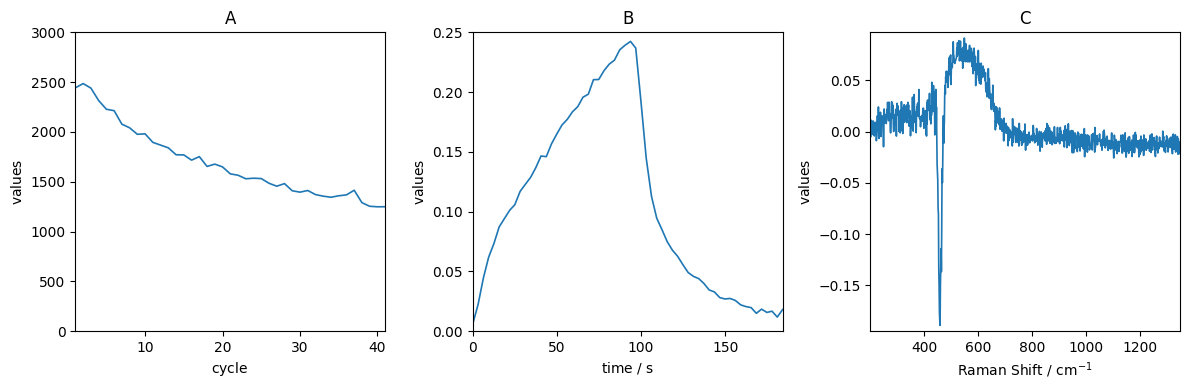

In [ ]:
cp  = cp_list[0]
loadings = cp.loadings

A = - cp.A
B = cp.B
C = - cp.C


# plot
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

A.plot(ax=axes[0], ylim=(0, 3000))
B.plot(ax=axes[1], ylim=(0, 0.25))
C.plot(ax=axes[2])

axes[0].set_title("A")
axes[1].set_title("B")
axes[2].set_title("C")

plt.tight_layout()
plt.show()


The A matrix reflects the intensitry evolution between the cycles. It is consistent with the slow evolution evidenced by PCA. Here the decrease from the first to last cycle is approx 50%. This variation probably encompasses the decrease of amplitudes and decrease of the mean score observed by PCA.  

The B matrix reflects the mean evoution od spectral intensity with a cycle, and C the averaged difference spectral profile. Both are very consistent with the concentration profile derived from the mean diference spectra (cf presentation)      